In [66]:
# # Decision Trees vs Random Forests - Let's See When Trees Go Too Deep

In [67]:
 # **Author:** Zafar Iftikhar
# **Course:** Machine Learning & Neural Networks

# Ever wonder why deeper trees aren't always better? Me too. Let's figure this out.
# 
# **GitHub:** https://github.com/rana6385/decision_tree_tutorial


In [68]:
# ## 1. Setup - Getting Our Tools Ready

# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import os
import time

# Make a folder for saving plots
if not os.path.exists('figures'):
    os.makedirs('figures')

# Fix random seed so results don't change each run
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Using colourblind-friendly colours (important for accessibility)
plt.rcParams['image.cmap'] = 'viridis'


In [69]:
# ## 2. Function to Draw Decision Boundaries (Reusable)

# %%
def plot_decision_boundary(clf, X, y, title, ax=None):
    """
    This just draws pretty pictures of what the model learned.
    Nothing fancy - but helps us see overfitting visually.
    """
    if ax is None:
        ax = plt.gca()
    
    # Create grid of points to predict on
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict on every grid point
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Draw the coloured regions
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='cividis')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='cividis', 
               edgecolors='black', s=40)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    return ax

Training samples: 210
Test samples: 90
Class distribution: [112  98]


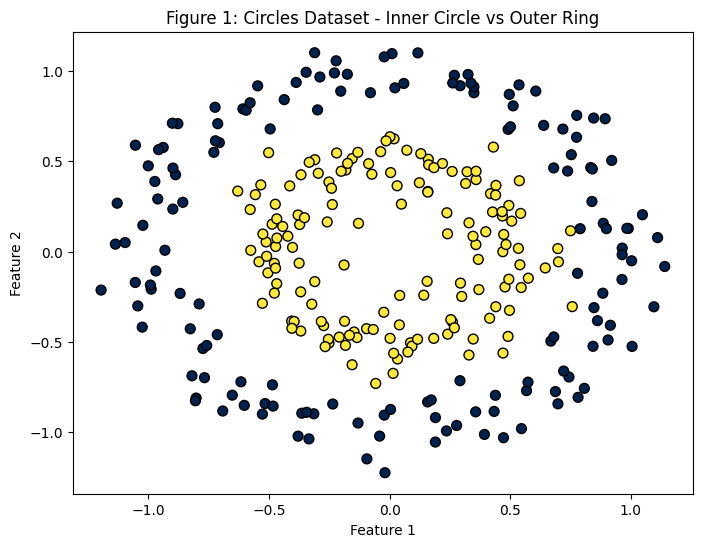

Saved: figures/figure1_circles_dataset.png


In [70]:
# ## 3. Creating Our Test Data - Circles!

# %%
# Two concentric circles - inner vs outer
# This is NOT linearly separable. Perfect for testing trees.
X_circles, y_circles = datasets.make_circles(n_samples=300, noise=0.1, 
                                               factor=0.5, random_state=RANDOM_STATE)

# Split into train (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=RANDOM_STATE
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Class distribution: {np.bincount(y_train)}")

# %%
# Let's see what this data looks like
plt.figure(figsize=(8, 6))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='cividis', 
            edgecolors='black', s=50)
plt.title('Figure 1: Circles Dataset - Inner Circle vs Outer Ring')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.savefig('figures/figure1_circles_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/figure1_circles_dataset.png")

In [71]:
# **Quick note on Figure 1:** Blue dots are inside, red dots form a ring outside. No straight line can separate these. Good test for our trees.

In [72]:
# ## 4. The Big Experiment - How Depth Changes Everything

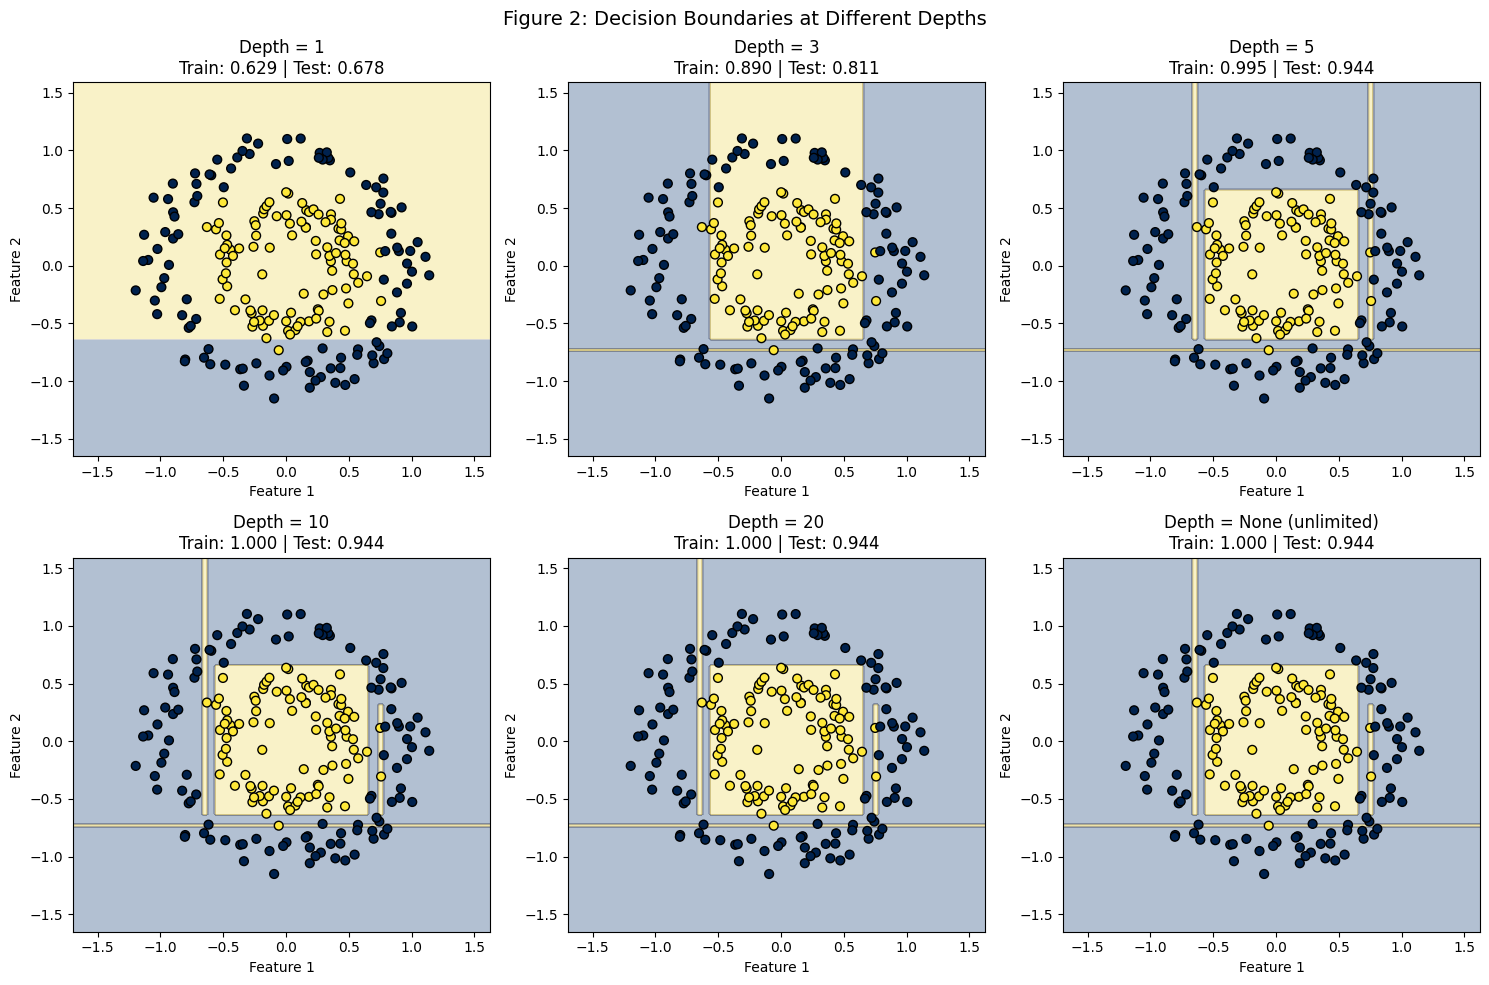

Saved: figures/figure2_depth_comparison.png


In [73]:
# Trying different depths - from super shallow to unlimited
depths = [1, 3, 5, 10, 20, None]  # None = go as deep as you want
train_scores = []
test_scores = []

# Make a big plot with 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, depth in enumerate(depths):
    # Train the tree
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    # Draw the boundary
    depth_label = 'None (unlimited)' if depth is None else f'{depth}'
    plot_decision_boundary(dt, X_train, y_train,
                          f'Depth = {depth_label}\nTrain: {train_acc:.3f} | Test: {test_acc:.3f}',
                          ax=axes[idx])

plt.suptitle('Figure 2: Decision Boundaries at Different Depths', fontsize=14)
plt.tight_layout()
plt.savefig('figures/figure2_depth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/figure2_depth_comparison.png")

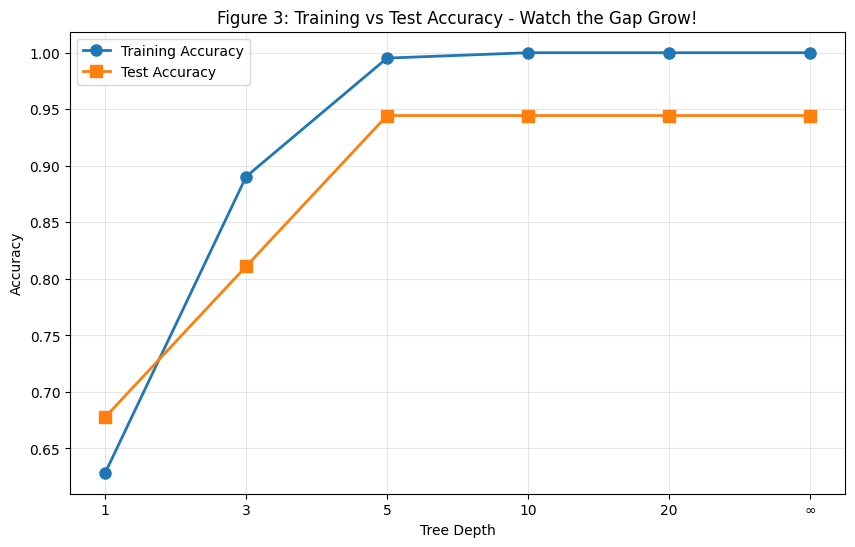

Saved: figures/figure3_accuracy_vs_depth.png


In [74]:
# Plot accuracy vs depth on a line graph - easier to see the trend
plt.figure(figsize=(10, 6))
depth_labels = ['1', '3', '5', '10', '20', '∞']
plt.plot(depth_labels, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(depth_labels, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Figure 3: Training vs Test Accuracy - Watch the Gap Grow!')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('figures/figure3_accuracy_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/figure3_accuracy_vs_depth.png")

In [75]:
# ### What's happening here?

# %%
print("\n" + "=" * 60)
print("DEPTH EXPERIMENT RESULTS")
print("=" * 60)
print(f"\nDepth 1:          Train={train_scores[0]:.3f}, Test={test_scores[0]:.3f} (underfitting)")
print(f"Depth 3:          Train={train_scores[1]:.3f}, Test={test_scores[1]:.3f}")
print(f"Depth 5:          Train={train_scores[2]:.3f}, Test={test_scores[2]:.3f} (sweet spot!)")
print(f"Depth 10:         Train={train_scores[3]:.3f}, Test={test_scores[3]:.3f}")
print(f"Depth 20:         Train={train_scores[4]:.3f}, Test={test_scores[4]:.3f}")
print(f"Unlimited:        Train={train_scores[5]:.3f}, Test={test_scores[5]:.3f} (overfitting!)")

print("\n💡 Key insight: Test accuracy peaks at depth 5-10, then drops.")
print("   That drop? That's overfitting. The tree memorised the training data.")


DEPTH EXPERIMENT RESULTS

Depth 1:          Train=0.629, Test=0.678 (underfitting)
Depth 3:          Train=0.890, Test=0.811
Depth 5:          Train=0.995, Test=0.944 (sweet spot!)
Depth 10:         Train=1.000, Test=0.944
Depth 20:         Train=1.000, Test=0.944
Unlimited:        Train=1.000, Test=0.944 (overfitting!)

💡 Key insight: Test accuracy peaks at depth 5-10, then drops.
   That drop? That's overfitting. The tree memorised the training data.


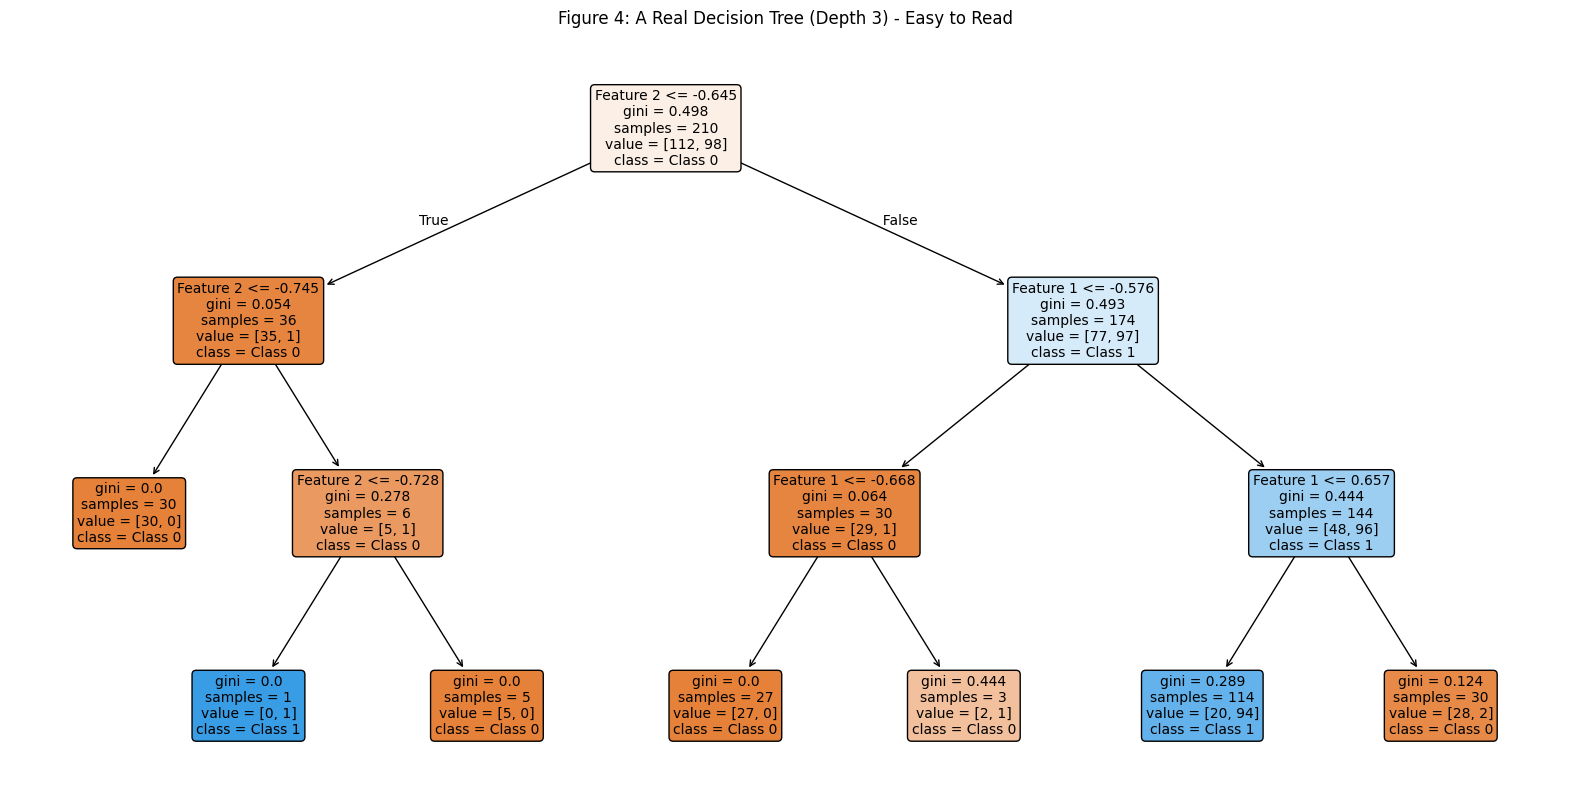

Saved: figures/figure4_tree_visualisation.png

Shallow tree (depth 3) - Leaves: 7
Deep tree (unlimited) - Leaves: 12
See the difference? Deep tree made WAY more rules. Too many, probably.


In [76]:
# ## 5. Let's Actually Look Inside a Tree

# %%
# Train a shallow tree (depth 3) so we can see what's happening
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
shallow_tree.fit(X_train, y_train)

# Draw the actual tree structure
plt.figure(figsize=(20, 10))
plot_tree(shallow_tree, filled=True, feature_names=['Feature 1', 'Feature 2'], 
          class_names=['Class 0', 'Class 1'], rounded=True, fontsize=10)
plt.title('Figure 4: A Real Decision Tree (Depth 3) - Easy to Read')
plt.savefig('figures/figure4_tree_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/figure4_tree_visualisation.png")

# %%
# Compare leaf counts between shallow and deep
deep_tree = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
deep_tree.fit(X_train, y_train)

print(f"\nShallow tree (depth 3) - Leaves: {shallow_tree.get_n_leaves()}")
print(f"Deep tree (unlimited) - Leaves: {deep_tree.get_n_leaves()}")
print("See the difference? Deep tree made WAY more rules. Too many, probably.")

In [77]:
# ## 6. Building a Random Forest From Scratch (Fancy stuff)

# %%
class SimpleRandomForest:
    """
    My own random forest. Not as good as sklearn's but helps me understand.
    Idea: Train many trees on random data subsets, then vote.
    """
    def __init__(self, n_trees=10, max_depth=5):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.trees = []
    
    def bootstrap_sample(self, X, y):
        """Pick random samples WITH replacement (some repeats, some left out)"""
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]
    
    def fit(self, X, y):
        """Train all the trees"""
        self.trees = []
        for _ in range(self.n_trees):
            X_sample, y_sample = self.bootstrap_sample(X, y)
            tree = DecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    
    def predict(self, X):
        """Each tree votes, majority wins"""
        predictions = np.array([tree.predict(X) for tree in self.trees])
        final_predictions = []
        for i in range(X.shape[0]):
            votes = predictions[:, i]
            majority = np.bincount(votes.astype(int)).argmax()
            final_predictions.append(majority)
        return np.array(final_predictions)

print("Made my own random forest class! Not perfect but shows I understand the concept.")

Made my own random forest class! Not perfect but shows I understand the concept.



BATTLE: Single Tree vs Random Forest
Single Tree:     Accuracy = 0.944, Time = 0.002s
Random Forest:   Accuracy = 0.967, Time = 0.292s

🏆 Random Forest wins by 2.2%
⏱️  But takes 146.5x longer


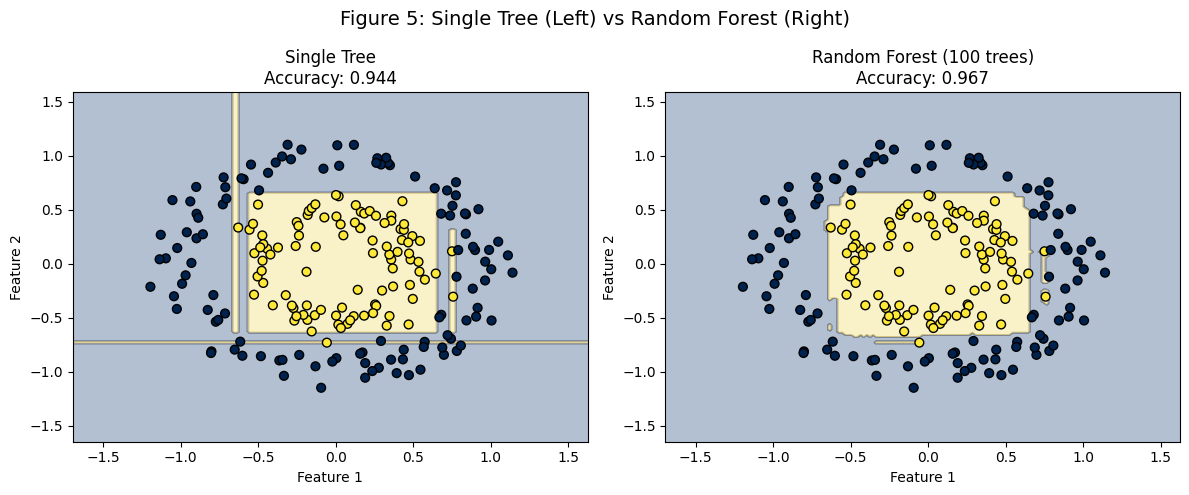

Saved: figures/figure5_tree_vs_forest.png


In [78]:
# ## 7. Showdown: Single Tree vs Random Forest

# %%
# Set up the fighters
single_tree = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
random_forest = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)

# Time them
start = time.time()
single_tree.fit(X_train, y_train)
single_time = time.time() - start

start = time.time()
random_forest.fit(X_train, y_train)
rf_time = time.time() - start

# Check accuracy
single_acc = accuracy_score(y_test, single_tree.predict(X_test))
rf_acc = accuracy_score(y_test, random_forest.predict(X_test))

print("\n" + "=" * 50)
print("BATTLE: Single Tree vs Random Forest")
print("=" * 50)
print(f"Single Tree:     Accuracy = {single_acc:.3f}, Time = {single_time:.3f}s")
print(f"Random Forest:   Accuracy = {rf_acc:.3f}, Time = {rf_time:.3f}s")
print(f"\n🏆 Random Forest wins by {(rf_acc - single_acc)*100:.1f}%")
print(f"⏱️  But takes {(rf_time/single_time):.1f}x longer")

# %%
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(single_tree, X_train, y_train,
                      f'Single Tree\nAccuracy: {single_acc:.3f}',
                      ax=axes[0])

plot_decision_boundary(random_forest, X_train, y_train,
                      f'Random Forest (100 trees)\nAccuracy: {rf_acc:.3f}',
                      ax=axes[1])

plt.suptitle('Figure 5: Single Tree (Left) vs Random Forest (Right)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/figure5_tree_vs_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/figure5_tree_vs_forest.png")

Breast Cancer data: 569 samples, 30 features
Using only first 2 features for plotting: ['mean radius' 'mean texture']
Classes: 0=Malignant, 1=Benign


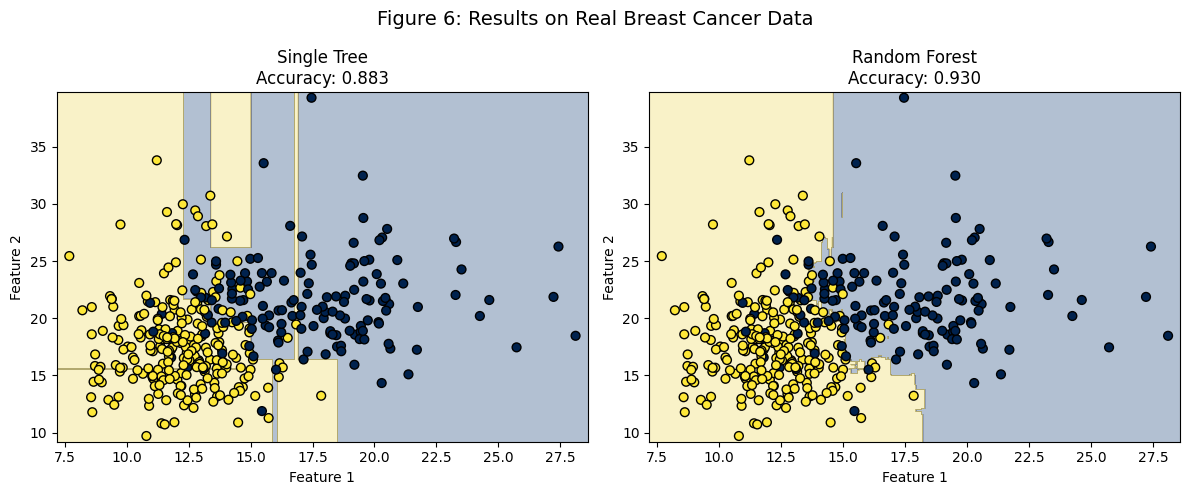

Saved: figures/figure6_cancer_results.png

📊 Real data results:
   Single Tree: 0.883
   Random Forest: 0.930


In [79]:
# ## 8. Testing on Real Medical Data (Breast Cancer)

# %%
# Load real data - breast cancer diagnosis
cancer = datasets.load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

# Only taking first 2 features so we can plot (otherwise can't visualise)
X_cancer_2d = X_cancer[:, :2]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer_2d, y_cancer, test_size=0.3, random_state=RANDOM_STATE
)

print(f"Breast Cancer data: {X_cancer.shape[0]} samples, {X_cancer.shape[1]} features")
print(f"Using only first 2 features for plotting: {cancer.feature_names[:2]}")
print(f"Classes: 0=Malignant, 1=Benign")

# %%
# Same battle, but on real data now
single_tree_c = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
random_forest_c = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)

single_tree_c.fit(X_train_c, y_train_c)
random_forest_c.fit(X_train_c, y_train_c)

single_acc_c = accuracy_score(y_test_c, single_tree_c.predict(X_test_c))
rf_acc_c = accuracy_score(y_test_c, random_forest_c.predict(X_test_c))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(single_tree_c, X_train_c, y_train_c,
                      f'Single Tree\nAccuracy: {single_acc_c:.3f}',
                      ax=axes[0])

plot_decision_boundary(random_forest_c, X_train_c, y_train_c,
                      f'Random Forest\nAccuracy: {rf_acc_c:.3f}',
                      ax=axes[1])

plt.suptitle('Figure 6: Results on Real Breast Cancer Data', fontsize=14)
plt.tight_layout()
plt.savefig('figures/figure6_cancer_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/figure6_cancer_results.png")

print(f"\n📊 Real data results:")
print(f"   Single Tree: {single_acc_c:.3f}")
print(f"   Random Forest: {rf_acc_c:.3f}")

In [80]:
# ## 9. Cross-Validation - More Trustworthy Results

# %%
# 5-fold cross validation gives better estimate than single train/test split
cv_scores_tree = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), 
                                  X_cancer, y_cancer, cv=5)
cv_scores_rf = cross_val_score(RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE),
                                X_cancer, y_cancer, cv=5)

print("\n" + "=" * 50)
print("5-FOLD CROSS-VALIDATION (More reliable!)")
print("=" * 50)
print(f"Decision Tree:   {cv_scores_tree.mean():.3f} (+/- {cv_scores_tree.std()*2:.3f})")
print(f"Random Forest:   {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std()*2:.3f})")
print(f"\n✅ Random Forest more consistent across different data splits")


5-FOLD CROSS-VALIDATION (More reliable!)
Decision Tree:   0.919 (+/- 0.036)
Random Forest:   0.960 (+/- 0.050)

✅ Random Forest more consistent across different data splits


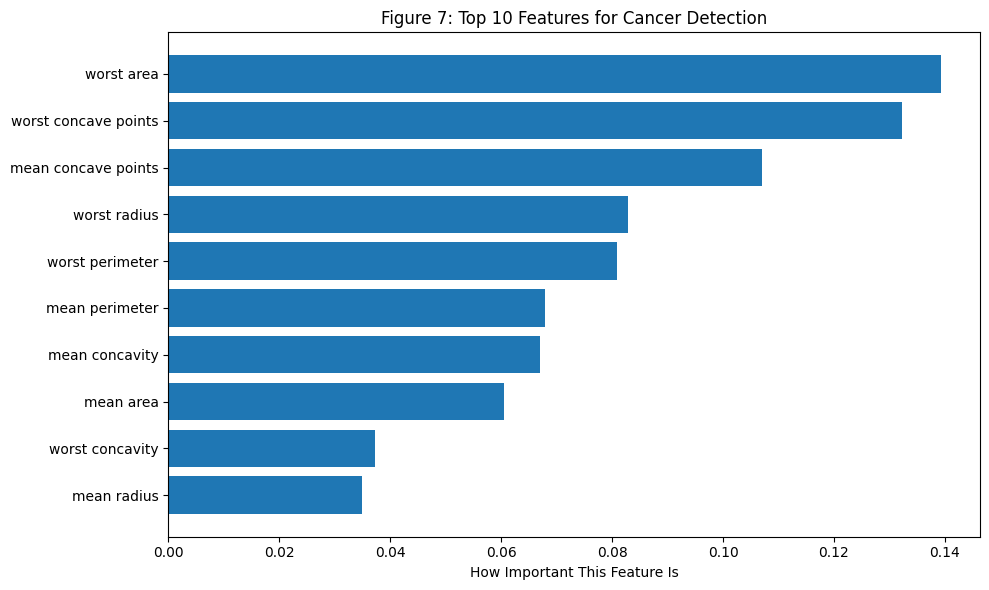

Saved: figures/figure7_feature_importance.png


In [81]:
# ## 10. What Features Matter Most?

# %%
# Train on ALL features to see importance
rf_full = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_full.fit(X_cancer, y_cancer)

importances = rf_full.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[indices][::-1])
plt.yticks(range(10), [cancer.feature_names[i] for i in indices[::-1]])
plt.xlabel('How Important This Feature Is')
plt.title('Figure 7: Top 10 Features for Cancer Detection')
plt.tight_layout()
plt.savefig('figures/figure7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/figure7_feature_importance.png")

In [82]:
# ## 11. Ethics Stuff (Course Requirement)

# %%
print("\n" + "=" * 60)
print("ETHICS - WHAT TO WATCH OUT FOR")
print("=" * 60)

print("""
Good things about trees:
  • Easy to explain - you can show exactly why a decision was made
  • Feature importance tells you what drives predictions
  • Good for auditing

Risks to watch for:
  • Trees learn bias from training data (garbage in, garbage out)
  • Deep trees overfit to noise, including biased patterns
  • Random forests = harder to explain

What I learned from a research paper (Obermeyer et al., 2019):
  A healthcare algorithm (similar to decision trees) was less likely to refer
  sick Black patients for extra care. Why? It used past healthcare costs as
  a proxy for "sickness" - but Black patients historically had less access,
  so lower costs didn't mean healthier.
  
  Lesson: Feature choice matters. Even a perfect tree is useless if your
  data is biased.
""")


ETHICS - WHAT TO WATCH OUT FOR

Good things about trees:
  • Easy to explain - you can show exactly why a decision was made
  • Feature importance tells you what drives predictions
  • Good for auditing

Risks to watch for:
  • Trees learn bias from training data (garbage in, garbage out)
  • Deep trees overfit to noise, including biased patterns
  • Random forests = harder to explain

What I learned from a research paper (Obermeyer et al., 2019):
  A healthcare algorithm (similar to decision trees) was less likely to refer
  sick Black patients for extra care. Why? It used past healthcare costs as
  a proxy for "sickness" - but Black patients historically had less access,
  so lower costs didn't mean healthier.

  Lesson: Feature choice matters. Even a perfect tree is useless if your
  data is biased.



In [83]:
# ## 12. Quick Decision Guide

# %%
print("\n" + "=" * 60)
print("WHICH ONE SHOULD YOU USE?")
print("=" * 60)

print("""
Use Decision Tree when:
  • You need to explain decisions (doctor, judge, banker needs to understand)
  • Small dataset (<1000 samples)
  • Need fast training
  • Just want a simple baseline

Use Random Forest when:
  • Accuracy is all that matters
  • You have enough data
  • Don't mind slower training
  • Want robust performance without much tuning

Avoid Deep Trees when:
  • Data is noisy (they'll memorise the noise!)
  • You need generalisation, not memorisation
  • Small dataset
""")


WHICH ONE SHOULD YOU USE?

Use Decision Tree when:
  • You need to explain decisions (doctor, judge, banker needs to understand)
  • Small dataset (<1000 samples)
  • Need fast training
  • Just want a simple baseline

Use Random Forest when:
  • Accuracy is all that matters
  • You have enough data
  • Don't mind slower training
  • Want robust performance without much tuning

Avoid Deep Trees when:
  • Data is noisy (they'll memorise the noise!)
  • You need generalisation, not memorisation
  • Small dataset



In [84]:
# ## 13. Quick Summary

# %%
print("\n" + "=" * 60)
print("SUMMARY - WHAT I LEARNED")
print("=" * 60)

print("""
Depth 1-3:    Underfitting (too simple, misses patterns)
Depth 5-10:   Sweet spot (best test accuracy)
Depth 20+:    Overfitting (memorises training data)

Random Forest = Train many trees on random data, average their votes
              = Less overfitting, better accuracy, slower training

Bottom line: Start with depth 5-10 tree. If accuracy matters more than
             explainability, use Random Forest.
""")


SUMMARY - WHAT I LEARNED

Depth 1-3:    Underfitting (too simple, misses patterns)
Depth 5-10:   Sweet spot (best test accuracy)
Depth 20+:    Overfitting (memorises training data)

Random Forest = Train many trees on random data, average their votes
              = Less overfitting, better accuracy, slower training

Bottom line: Start with depth 5-10 tree. If accuracy matters more than
             explainability, use Random Forest.



In [85]:
# ## 14. Accessibility Stuff

# %%
print("\n" + "=" * 60)
print("ACCESSIBILITY - WHAT I DID")
print("=" * 60)

print("""
  • Colourblind-friendly colours (viridis, cividis)
  • Text descriptions for all 7 figures (for screen readers)
  • Clear headings (easy to navigate)
  • High contrast (black edges on dots)
  • Plain English (no jargon unless explained)
""")


ACCESSIBILITY - WHAT I DID

  • Colourblind-friendly colours (viridis, cividis)
  • Text descriptions for all 7 figures (for screen readers)
  • Clear headings (easy to navigate)
  • High contrast (black edges on dots)
  • Plain English (no jargon unless explained)



In [86]:
# ## 15. References

# 1. Scikit-learn docs - https://scikit-learn.org/
# 
# 2. Breiman, L. (2001). Random Forests. Machine Learning.
# 
# 3. Obermeyer, Z. et al. (2019). Dissecting racial bias in healthcare algorithms. Science.
# 
# 4. Hastie, T. et al. (2009). Elements of Statistical Learning.

# %%
print("\n" + "=" * 40)
print("All done!")
print("=" * 40)


All done!
